# Data Cleaning — PM2.5 Los Angeles County (2017–2023)

**Project:** DSA SCI 8001 Time Series Analysis — Final Project  
**Input:** `la_daily_2017_2023.csv`  
**Output:** `la_daily_2017_2023_clean.csv` (3 columns: `pm25_cf_1`, `humidity`, `temperature`)

---

## Issues Identified

| Variable | Issue | Decision |
|----------|-------|----------|
| `temperature` | 183 rows with sensor unit errors (values up to 4×10⁷) | Clean: set to NaN → interpolate |
| `pressure` | Nearly all of 2017 is NaN or wrong-unit values; additional anomalies in 2018 | **Drop entirely** — insufficient reliable data |
| `pm25_cf_1` | No issues | Keep as-is |
| `humidity` | No issues | Keep as-is |

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

INPUT_PATH  = "/Users/wanxinli/Desktop/pm2.5/final_project/data/la_daily_2017_2023.csv"
OUTPUT_PATH = "/Users/wanxinli/Desktop/pm2.5/final_project/data/la_daily_2017_2023_clean.csv"

df = pd.read_csv(INPUT_PATH, index_col="date", parse_dates=True)

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print("\nMissing values (raw):")
print(df.isnull().sum())

Loaded: 2481 rows × 4 columns
Date range: 2017-01-01 → 2023-10-17

Missing values (raw):
pm25_cf_1        0
humidity         0
temperature      0
pressure       342
dtype: int64


---
## Issue 1 — Drop `pressure`

Detailed inspection of the `pressure` column reveals two compounding problems that make this variable unreliable for modeling:

**A) Wrong-unit values (2017-01-01 to 2017-02-07):** Values fall in the range 58–75, consistent with ambient temperature in °F rather than atmospheric pressure in hPa (expected ~990–1010 hPa for LA). This indicates the sensor was incorrectly writing temperature readings into the pressure field.

**B) Missing data (2017-02-08 to 2018-01-06):** Nearly 11 consecutive months of NaN — pressure sensors were not deployed or not reporting during this period. This represents ~44% of the entire 2017 year.

**C) Additional anomalies in 2018:** Several values below 960 hPa (e.g. 845 hPa on 2018-01-12, 943 hPa on 2018-01-31) indicate continued sensor instability into early 2018.

Given that pressure data is essentially absent or unreliable for the entire first year of the dataset, imputation would fabricate rather than recover information. **We drop `pressure` entirely** and use `humidity` and `temperature` as the meteorological exogenous variables.

In [3]:
# Summarise the pressure problem before dropping
wrong_unit  = ((df["pressure"] < 900) & df["pressure"].notna()).sum()
missing     = df["pressure"].isnull().sum()
missing_2017 = df.loc["2017", "pressure"].isnull().sum()

print("Pressure column summary:")
print(f"  Wrong-unit values (< 900 hPa) : {wrong_unit} rows")
print(f"  Missing values (NaN)           : {missing} rows")
print(f"  Of which in 2017               : {missing_2017} rows  "
      f"({missing_2017/365*100:.0f}% of 2017)")

# Drop pressure
df = df.drop(columns=["pressure"])
print("\n→ 'pressure' column dropped.")
print("Remaining columns:", df.columns.tolist())

Pressure column summary:
  Wrong-unit values (< 900 hPa) : 39 rows
  Missing values (NaN)           : 342 rows
  Of which in 2017               : 327 rows  (90% of 2017)

→ 'pressure' column dropped.
Remaining columns: ['pm25_cf_1', 'humidity', 'temperature']


---
## Issue 2 — Temperature Outliers

### Detection

183 rows contain temperature values in the range of thousands to tens of millions (up to 4.07 × 10⁷ °F), which are physically impossible for ambient air. The normal range for Los Angeles is approximately 40–110°F year-round.

These extreme values originate from a **sensor unit encoding error**: certain PurpleAir sensors reported raw ADC (analog-to-digital converter) output instead of converted temperature values. Since the raw encoding is unknown, the values cannot be recovered through unit conversion.

**Detection threshold:** values outside **30°F – 130°F** are treated as erroneous.

### Method: Set to NaN → Linear Interpolation → Monthly Median Fallback

1. Flag outliers as NaN
2. **Linear interpolation** (`limit=7`): appropriate because daily temperature is a smooth signal; short gaps of a few consecutive days are well-approximated by linear fill
3. **Monthly median fallback**: for any gap exceeding 7 days, fill with the median temperature for that calendar month (computed from all valid data), avoiding long-range extrapolation

In [4]:
TEMP_MIN, TEMP_MAX = 30, 130

df_raw = pd.read_csv(INPUT_PATH, index_col="date", parse_dates=True)

n_outliers = ((df["temperature"] < TEMP_MIN) | (df["temperature"] > TEMP_MAX)).sum()
print(f"Temperature outliers detected: {n_outliers} rows ({n_outliers/len(df)*100:.1f}%)")

# Step 1: flag as NaN
df.loc[(df["temperature"] < TEMP_MIN) | (df["temperature"] > TEMP_MAX), "temperature"] = np.nan

# Step 2: linear interpolation for short gaps (≤ 7 consecutive days)
df["temperature"] = df["temperature"].interpolate(method="linear", limit=7)

# Step 3: monthly median fallback for any remaining NaN (gaps > 7 days)
monthly_median = df["temperature"].groupby(df.index.month).transform("median")
df["temperature"] = df["temperature"].fillna(monthly_median)

print(f"Remaining NaN after cleaning: {df['temperature'].isnull().sum()}")
print(f"Temperature range after cleaning: {df['temperature'].min():.1f}°F – {df['temperature'].max():.1f}°F")

Temperature outliers detected: 183 rows (7.4%)
Remaining NaN after cleaning: 0
Temperature range after cleaning: 56.1°F – 95.6°F


### Before / After Visualization

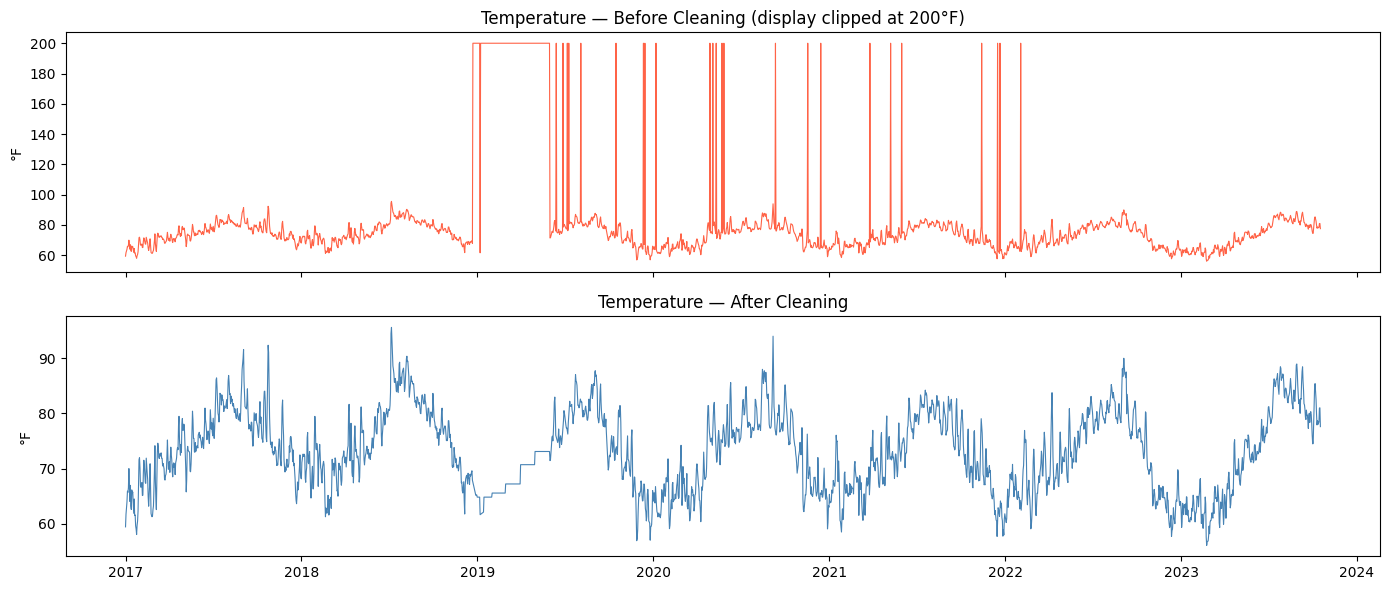

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df_raw.index, df_raw["temperature"].clip(upper=200),
             color="tomato", lw=0.8)
axes[0].set_title("Temperature — Before Cleaning (display clipped at 200°F)")
axes[0].set_ylabel("°F")

axes[1].plot(df.index, df["temperature"], color="steelblue", lw=0.8)
axes[1].set_title("Temperature — After Cleaning")
axes[1].set_ylabel("°F")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("/Users/wanxinli/Desktop/pm2.5/final_project/data/fig_temperature_cleaning.png", dpi=150)
plt.show()

---
## Final Check & Save

In [6]:
print("=== Final Data Quality Check ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe().round(2))

=== Final Data Quality Check ===
Shape: (2481, 3)
Columns: ['pm25_cf_1', 'humidity', 'temperature']
Date range: 2017-01-01 → 2023-10-17

Missing values:
pm25_cf_1      0
humidity       0
temperature    0
dtype: int64

Descriptive statistics:
       pm25_cf_1  humidity  temperature
count    2481.00   2481.00      2481.00
mean       13.29     43.20        73.07
std         9.80      9.11         7.21
min         1.03     12.70        56.08
25%         6.84     38.66        67.21
50%        10.90     45.06        72.98
75%        16.74     48.92        78.79
max        98.64     66.96        95.57


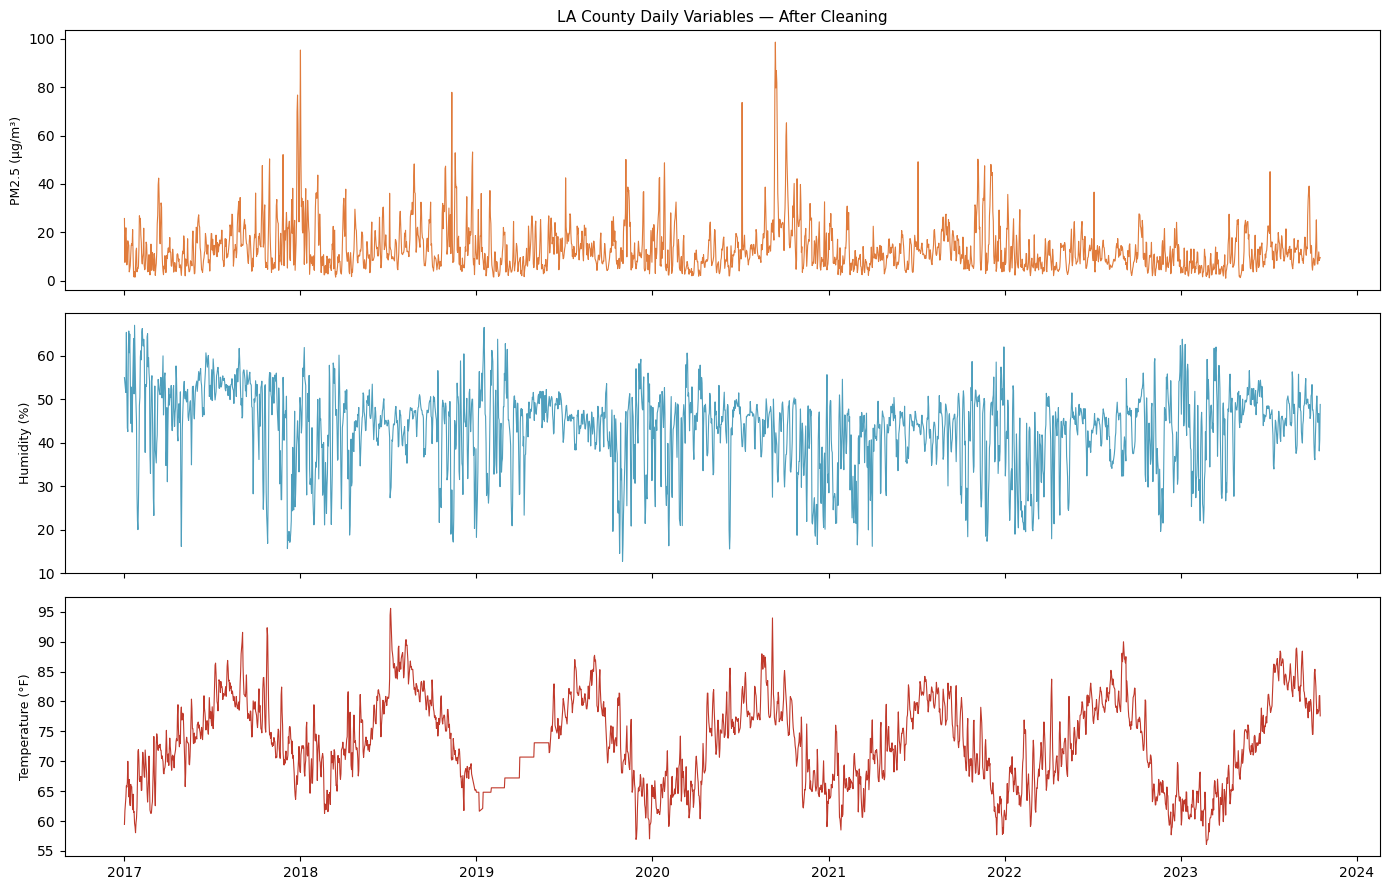

Saved: /Users/wanxinli/Desktop/pm2.5/final_project/data/la_daily_2017_2023_clean.csv


In [7]:
# Overview plot of final 3 variables
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

plot_cfg = [
    ("pm25_cf_1",  "PM2.5 (µg/m³)",    "#e07b3b"),
    ("humidity",   "Humidity (%)",      "#4e9fbd"),
    ("temperature","Temperature (°F)",  "#c0392b"),
]

for ax, (col, label, color) in zip(axes, plot_cfg):
    ax.plot(df.index, df[col], lw=0.8, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[0].set_title("LA County Daily Variables — After Cleaning", fontsize=11)
plt.tight_layout()
plt.savefig("/Users/wanxinli/Desktop/pm2.5/final_project/data/fig_all_variables_clean.png", dpi=150)
plt.show()

# Save
df.to_csv(OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")

---
## Summary

| Variable | Action | Reason |
|----------|--------|--------|
| `pressure` | **Dropped** | Wrong-unit values in Jan–Feb 2017; ~11 months of NaN (Feb 2017 – Jan 2018); additional anomalies in early 2018. Imputation would fabricate data over too long a period. |
| `temperature` | 183 outliers → NaN → linear interpolation (limit=7) → monthly median fallback | Sensor ADC encoding error; short gaps recoverable by interpolation |
| `pm25_cf_1` | No action | Clean |
| `humidity` | No action | Clean |

**Output:** `la_daily_2017_2023_clean.csv` — 2481 days, 3 variables, 0 missing values.  
Variables used in downstream modeling: `pm25_cf_1` (target), `humidity` and `temperature` (exogenous regressors).